# Plotting heatmap of single frame as illustration of monolayer heights

In [1]:
import sys
import json
import imageio
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from cmcrameri import cm
from scipy.ndimage import gaussian_filter
from matplotlib_scalebar.scalebar import ScaleBar


sys.path.append("scripts/utils")
from Microscopes import Tomocube

data_path = "../../../../hdd_data/silja/Monolayers/"

### Files used for figures in paper on Three Dimensional Dynamics of Epithelial Monolayers

Fig. 1A: `250904.114139.MDCK-li.001.Group2.B1.T001P01_HT3D_10-48-50.tiff`

In [2]:
_3DQPI  = Tomocube()
dataset = "MDCK_20250904_B1-1"

config  = json.load(open(f"configs/{dataset}.json"))
stack   = imageio.v2.imread(f"{data_path}misc/250904.114139.MDCK-li.001.Group2.B1.T001P01_HT3D_10-48-50.tiff") * _3DQPI.ri_conversion


In [3]:
image = stack[1, 300:800, 500:1000]
image = image + config["calibration"]["nshift"]

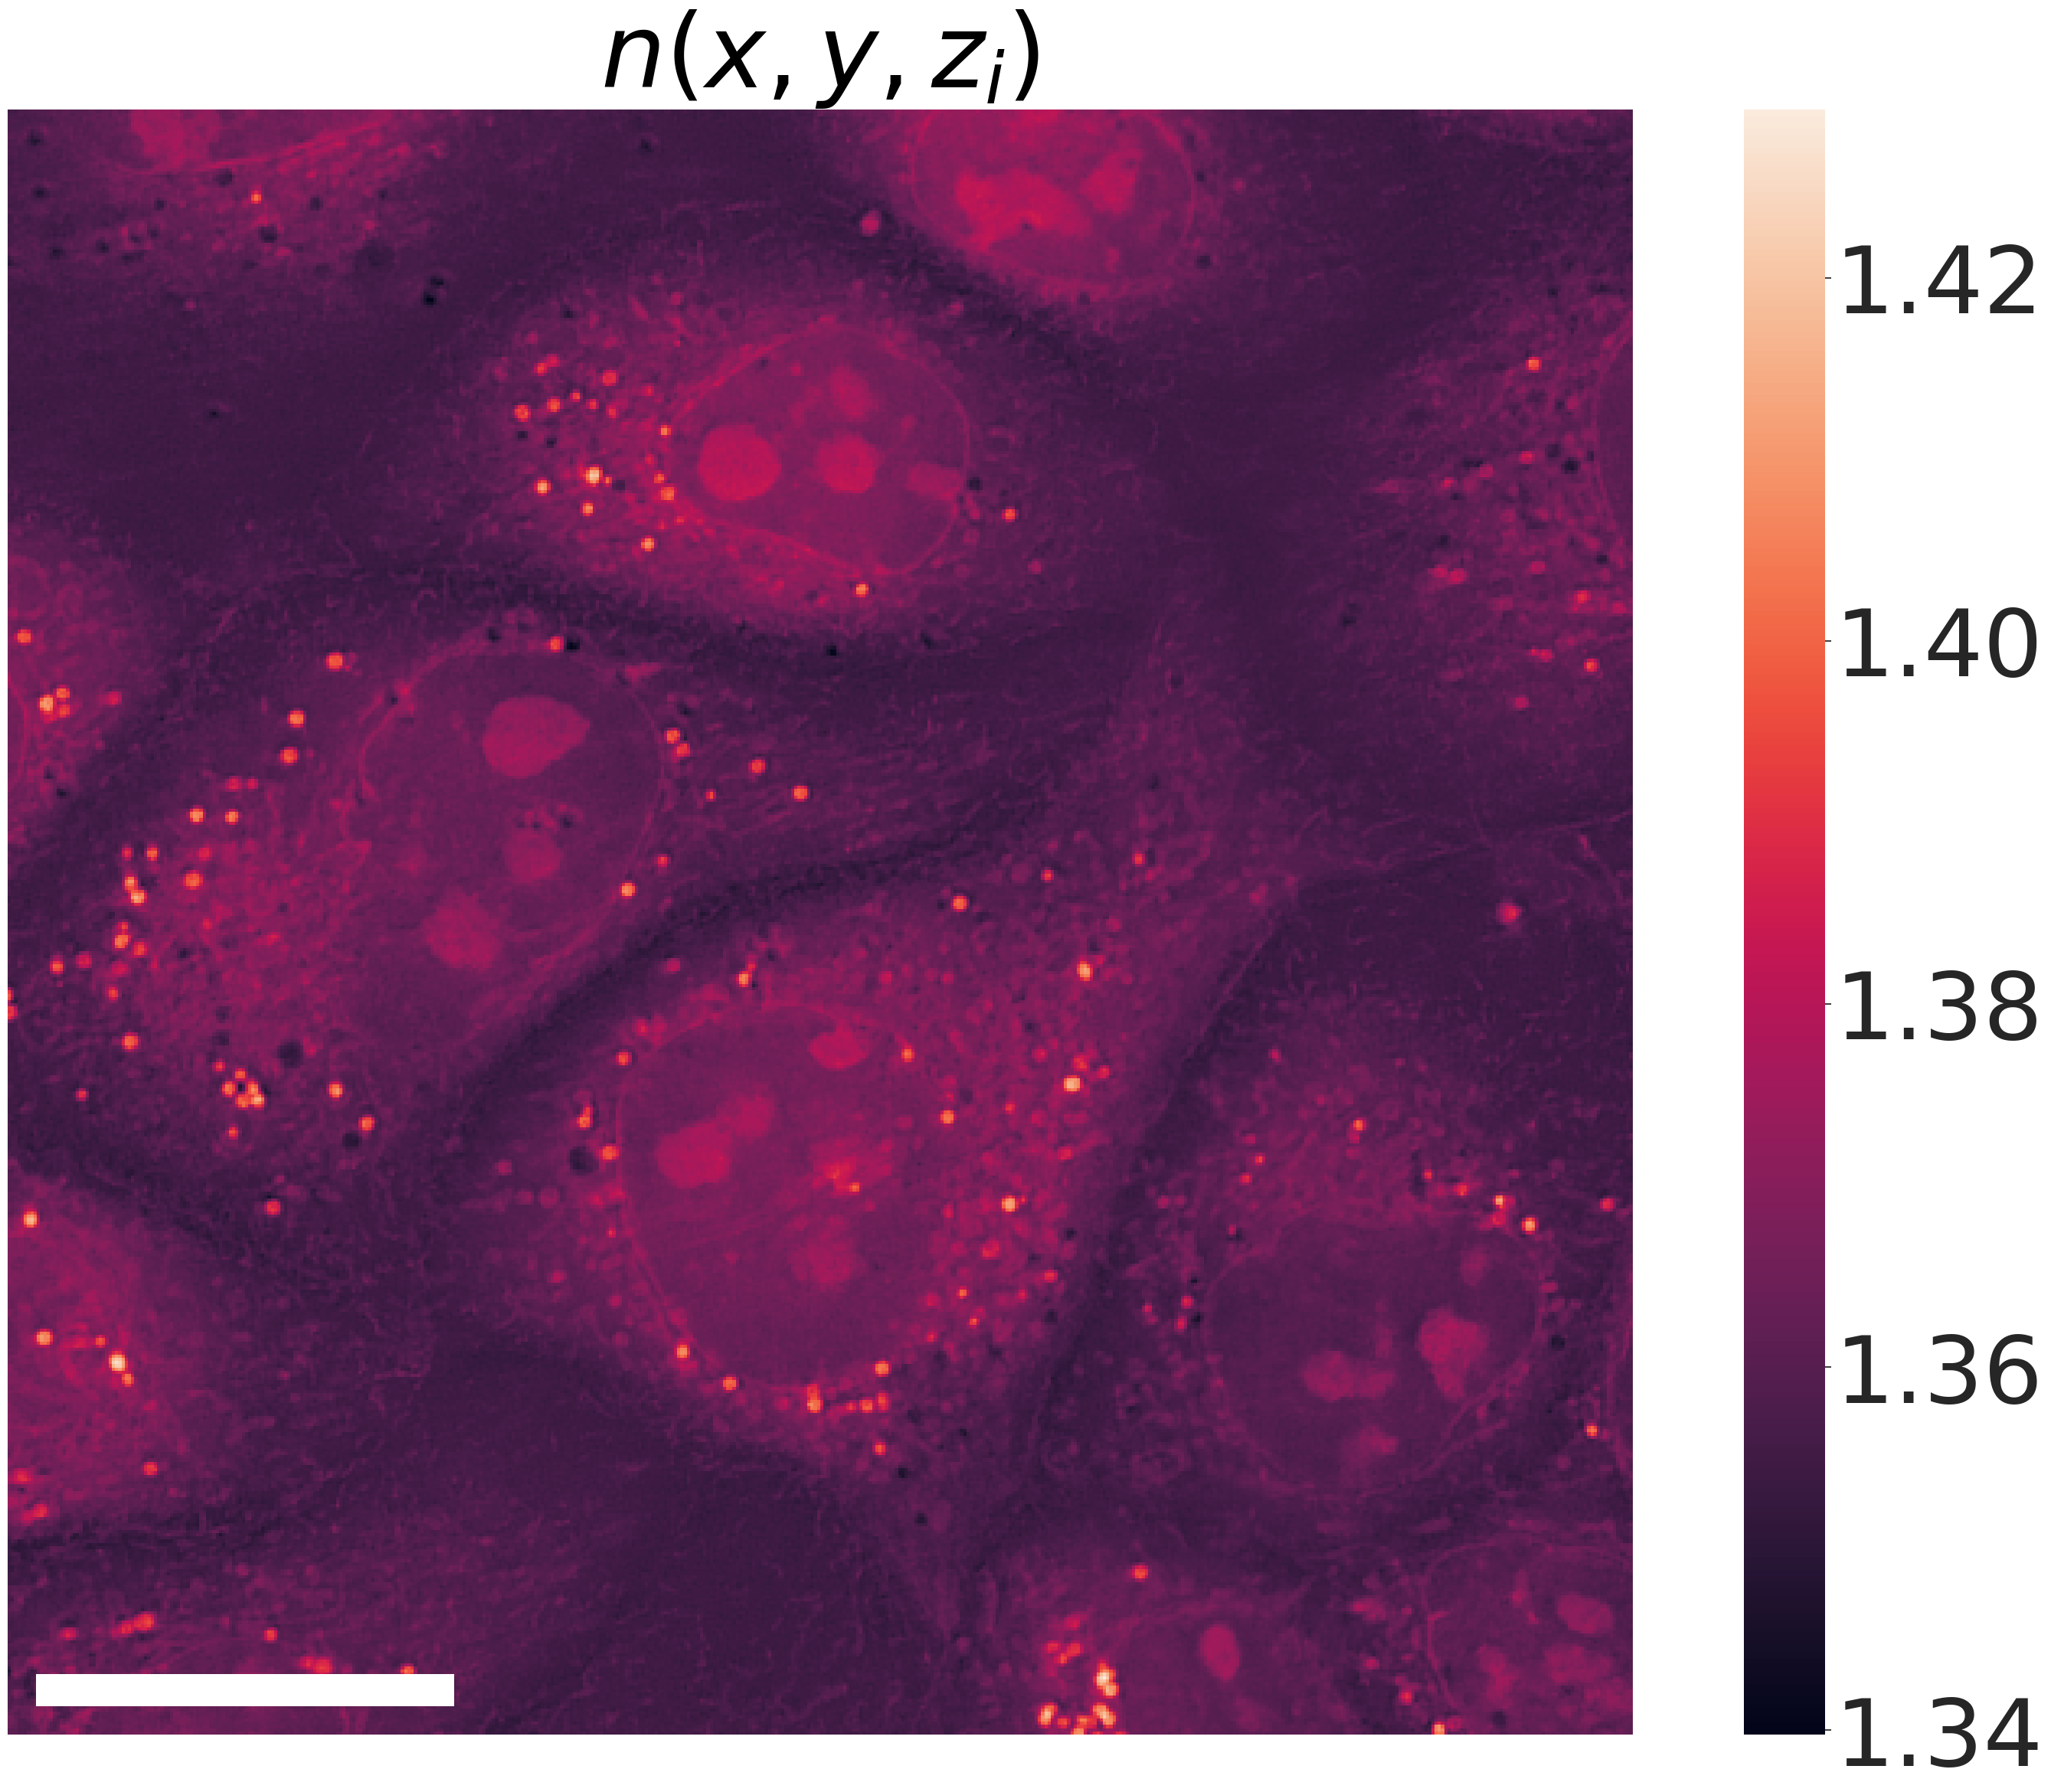

In [4]:
fig, ax = plt.subplots(1,1, figsize=(32,26))
sns.set_theme(style='ticks', palette='bright', font_scale=8)


sns.heatmap(image, square=True, cmap="rocket", xticklabels=False, yticklabels=False,)

sb = ScaleBar(_3DQPI.pix_to_um, 'um', box_alpha=0, color="w", height_fraction=2e-2, scale_loc="none", fixed_value=20)
sb.location = 'lower left'
ax.add_artist(sb)
ax.set(title=rf"$n(x,y,z_i)$")

fig.tight_layout()

In [5]:
# Save figure
# fig.savefig(f"figs/Elife/subfigures/ri_heatmap.png", dpi=100)